In [1]:
pip install yfinance pandas numpy statsmodels matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [170]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

We'll pick a small universe of stocks from the same sector (e.g., financials) to increase the chance of finding cointegrated pairs.

In [171]:
# Universe of stocks (financial sector)
tickers = ['JPM', 'BAC', 'WFC', 'C', 'GS', 'MS', 'USB', 'PNC']
# Broad Regional Bank Universe
# tickers = ['PNC', 'USB', 'TFC', 'FITB', 'HBAN', 'RF', 'KEY', 'MTB', 'CFG', 'ZION', 'WAL', 'EWBC', 'WBS', 'SSB', 'COLB']
# Full Financial Sector Mix
# tickers = ['JPM', 'BAC', 'WFC', 'C', 'GS', 'MS', 'USB', 'PNC', 'TFC', 'BK', 'SCHW', 'COF', 'ALLY', 'FITB', 'HBAN']
#Large-cap biopharma
# tickers = ['AMGN', 'GILD', 'REGN', 'BIIB', 'VRTX', 'INCY', 'ALNY']
#Mid-cap biopharma
# tickers = ['BMRN','NBIX','UTHR','EXEL','HALO','PTCT']

# Download daily adjusted close prices
start = '2019-01-01'
end = '2024-12-31'
prices = yf.download(tickers, start=start, end=end, auto_adjust=True)['Close']


# Drop any tickers with too many missing values
prices = prices.dropna(axis=1, thresh=int(0.8 * len(prices)))
print(f"Downloaded prices for {prices.shape[1]} stocks")
prices.head()

[*********************100%***********************]  8 of 8 completed

Downloaded prices for 8 stocks


Ticker,BAC,C,GS,JPM,MS,PNC,USB,WFC
Date,,,,,,,,
2019-01-02,20.945082,41.849670,145.391647,81.250206,32.492096,91.572235,34.746292,38.665245
2019-01-03,20.609425,41.091335,143.261871,80.095490,31.913031,91.156013,34.259022,38.360477
2019-01-04,21.465351,43.100552,147.944016,83.048271,33.215935,93.437431,35.106133,39.497200
2019-01-07,21.448570,43.475819,148.763840,83.105995,33.545677,93.229340,34.941204,39.241840
2019-01-08,21.406609,43.358551,148.214478,82.949280,33.336575,93.375778,35.166092,39.159481


We test every pair of stocks for cointegration using the Engle‑Granger test.


In [172]:
def find_cointegrated_pairs(data, pvalue_threshold=0.05):
    """
    Finds all cointegrated pairs in a DataFrame of price series.
    Returns a DataFrame with pair names and p-values.
    """
    n = data.shape[1]
    keys = data.columns
    pairs = []
    pvalues = []
    
    for i in range(n):
        for j in range(i+1, n):
            stock1 = keys[i]
            stock2 = keys[j]
            result = coint(data[stock1], data[stock2])
            pvalue = result[1]
            if pvalue < pvalue_threshold:
                pairs.append((stock1, stock2))
                pvalues.append(pvalue)
    
    return pd.DataFrame({'pair': pairs, 'pvalue': pvalues}).sort_values('pvalue')

# Find cointegrated pairs
coint_pairs = find_cointegrated_pairs(prices, pvalue_threshold=0.05)
print(f"Found {len(coint_pairs)} cointegrated pairs:")
coint_pairs

Found 1 cointegrated pairs:


,pair,pvalue
0,"(BAC, PNC)",0.001042


In [173]:
##Pick the pair with the lowest p‑value (strongest cointegration).

In [174]:
best_pair = coint_pairs.iloc[0]['pair']
stock1, stock2 = best_pair
print(f"Selected pair: {stock1} – {stock2}")

Selected pair: BAC – PNC


We use a linear regression (OLS) on the full sample to get the hedge ratio.

Hedge ratio (β): 4.3543


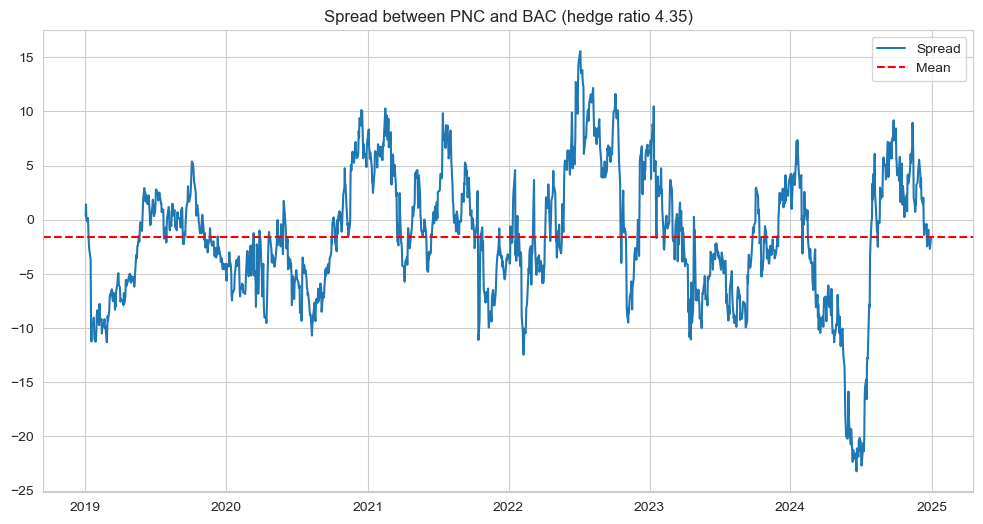

In [175]:
# Get price series for the pair
S1 = prices[stock1]
S2 = prices[stock2]

# Add constant for regression
S1_const = sm.add_constant(S1)
model = sm.OLS(S2, S1_const).fit()
hedge_ratio = model.params[stock1]
print(f"Hedge ratio (β): {hedge_ratio:.4f}")

# Calculate spread
spread = S2 - hedge_ratio * S1

# Plot the spread
plt.figure(figsize=(12,6))
plt.plot(spread.index, spread, label='Spread')
plt.axhline(y=spread.mean(), color='r', linestyle='--', label='Mean')
plt.title(f'Spread between {stock2} and {stock1} (hedge ratio {hedge_ratio:.2f})')
plt.legend()
plt.show()

We'll use a rolling window (e.g., 504 days) to compute the mean and standard deviation of the spread, then calculate the z‑score.

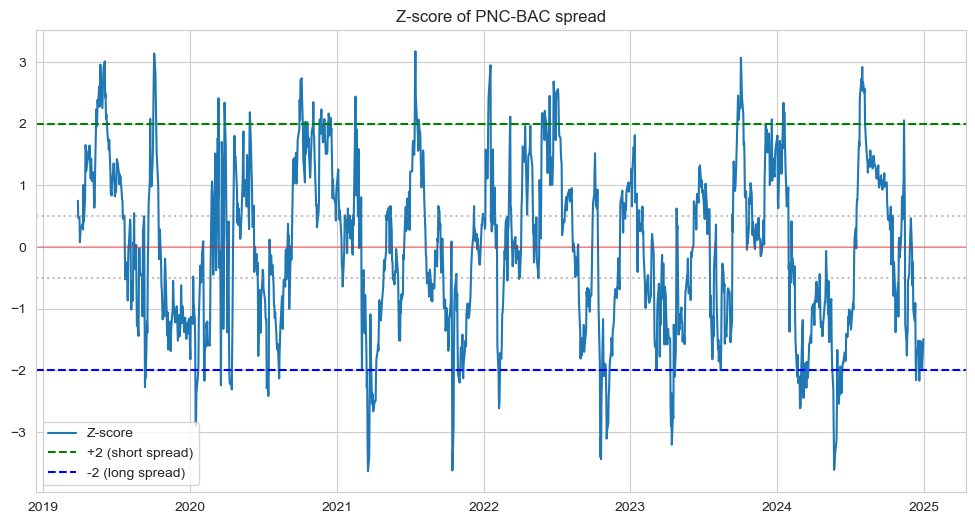

In [176]:
window = 60  # rolling window for mean and std

# Rolling mean and std of spread
spread_mean = spread.rolling(window=window, min_periods=window).mean()
spread_std = spread.rolling(window=window, min_periods=window).std()

# Z-score
z_score = (spread - spread_mean) / spread_std

# Plot z-score with thresholds
plt.figure(figsize=(12,6))
plt.plot(z_score.index, z_score, label='Z-score')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.axhline(y=2, color='g', linestyle='--', label='+2 (short spread)')
plt.axhline(y=-2, color='b', linestyle='--', label='-2 (long spread)')
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
plt.axhline(y=-0.5, color='gray', linestyle=':', alpha=0.5)
plt.title(f'Z-score of {stock2}-{stock1} spread')
plt.legend()
plt.show()

We simulate a strategy with:

    Entry: when z‑score crosses above +2 (short spread) or below -2 (long spread).

    Exit: when z‑score crosses back to 0.

    Position sizing: invest a fixed capital (e.g., $10,000) per trade.

    Transaction costs: assume 0.1% per trade (10 bps) for commission + slippage.

We'll create a DataFrame to track positions and P&L.

In [177]:
# Initialize DataFrame to store signals and positions
df = pd.DataFrame(index=z_score.index)
df['z_score'] = z_score
df['spread'] = spread
df['position'] = 0  # 1 = long spread (long S2, short S1), -1 = short spread (short S2, long S1)

# Generate entry/exit signals
threshold_entry = 2.0
threshold_exit = 0.0

in_position = 0
for i in range(1, len(df)):
    if in_position == 0:
        if df['z_score'].iloc[i] > threshold_entry:
            df.loc[df.index[i], 'position'] = -1   # short spread
            in_position = -1
        elif df['z_score'].iloc[i] < -threshold_entry:
            df.loc[df.index[i], 'position'] = 1    # long spread
            in_position = 1
    else:
        # exit condition: cross zero (or opposite threshold)
        if in_position == -1 and df['z_score'].iloc[i] < threshold_exit:
            df.loc[df.index[i], 'position'] = 0
            in_position = 0
        elif in_position == 1 and df['z_score'].iloc[i] > -threshold_exit:
            df.loc[df.index[i], 'position'] = 0
            in_position = 0
        else:
            df.loc[df.index[i], 'position'] = in_position

# Forward fill the position (so it stays constant between trades)
df['position'] = df['position'].replace(0, np.nan).ffill().fillna(0)

# Verify signal generation
df['position'].value_counts()

-1.0    745
 1.0    674
 0.0     90
Name: position, dtype: int64

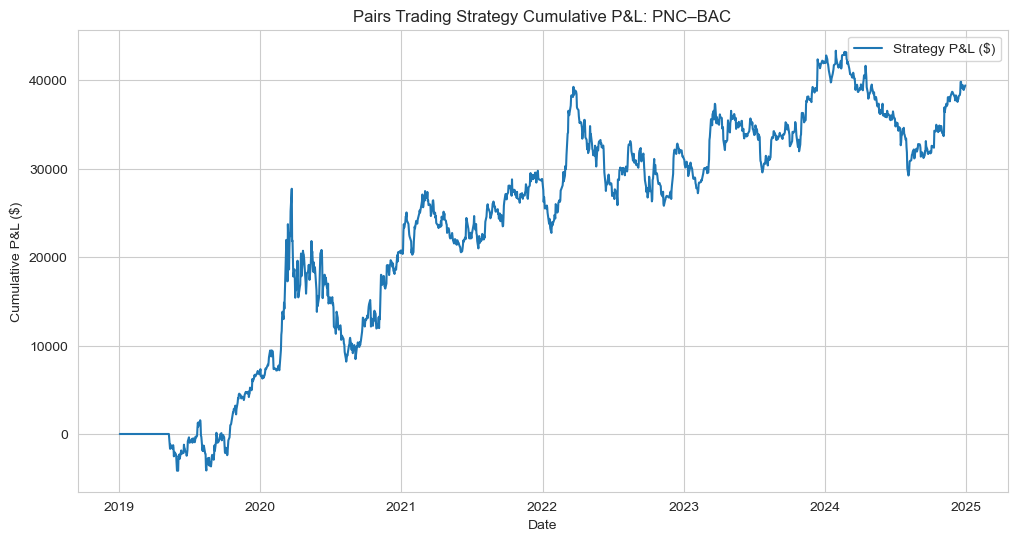

In [178]:
##We need to compute daily P&L based on the positions.

# Daily returns of the two stocks
ret1 = S1.pct_change()
ret2 = S2.pct_change()

# Strategy daily return (ignoring capital allocation)
# For long spread (position=1): we are long S2 and short S1
# P&L = (ret2 - hedge_ratio * ret1) * notional
# We'll use a notional of $10,000 on the spread (i.e., $10,000 exposure to the spread)
# So daily return in dollars = position * (ret2 - hedge_ratio * ret1) * 10000
# But we can also compute a percentage return relative to the capital at risk.
# For simplicity, we'll compute a return series assuming we risk $10,000 per trade.
# The actual capital required might be higher because of margin, but we ignore that.

df['ret1'] = ret1
df['ret2'] = ret2
df['hedge_ratio'] = hedge_ratio  # constant for now

# Daily P&L in dollars (assume $10,000 notional for the spread)
df['pnl_dollars'] = df['position'] * (df['ret2'] - df['hedge_ratio'] * df['ret1']) * 10000

# Subtract transaction costs
# We approximate transaction cost as 0.1% of the traded notional when position changes.
# Notional traded when entering or exiting is roughly $10,000 (both legs combined).
# So cost = 0.001 * 10000 = $10 per trade (one-way). For round trip, $20.
# We'll detect changes in position.
df['position_change'] = df['position'].diff().fillna(0)
# When change != 0, we incur a cost. But note that a change from -1 to 1 would involve two trades (close old, open new) – we'll simplify and apply cost only on entry/exit.
# For each change, we incur one-way cost.
df['cost'] = np.abs(df['position_change']) * 10   # $10 per change
df['pnl_net'] = df['pnl_dollars'] - df['cost']

# Cumulative P&L
df['cum_pnl'] = df['pnl_net'].cumsum()

# Plot equity curve
plt.figure(figsize=(12,6))
plt.plot(df.index, df['cum_pnl'], label='Strategy P&L ($)')
plt.title(f'Pairs Trading Strategy Cumulative P&L: {stock2}–{stock1}')
plt.xlabel('Date')
plt.ylabel('Cumulative P&L ($)')
plt.legend()
plt.show()

In [179]:
## Compute key statistics.

# Total return
total_return = df['cum_pnl'].iloc[-1]
print(f"Total P&L: ${total_return:.2f}")

# Annualised Sharpe ratio (assuming 504 trading days)
daily_returns = df['pnl_net'] / 10000  # convert to percentage return relative to $10,000 capital? Actually Sharpe is usually based on percentage returns, but we have dollar P&L.
# Better: compute percentage return relative to average capital employed.
# For simplicity, we'll assume we always have $10,000 at risk, so daily return = pnl_net / 10000.
strategy_returns = df['pnl_net'] / 10000
sharpe = np.sqrt(252) * strategy_returns.mean() / strategy_returns.std()
print(f"Sharpe Ratio (annualised): {sharpe:.2f}")

# Maximum drawdown
cumulative = df['cum_pnl']
running_max = cumulative.expanding().max()
drawdown = cumulative - running_max
max_drawdown = drawdown.min()
print(f"Maximum Drawdown: ${max_drawdown:.2f}")

# Win rate
trades = df[df['position_change'] != 0].copy()
# We need to group trades. Simpler: compute trade returns by cumulating P&L between entry and exit.
# We'll skip for brevity but you can add later.

# Number of trades
num_trades = (df['position_change'].abs() > 0).sum()
print(f"Number of trades (one-way): {num_trades}")

Total P&L: $39393.65
Sharpe Ratio (annualised): 0.56
Maximum Drawdown: $-19534.45
Number of trades (one-way): 22


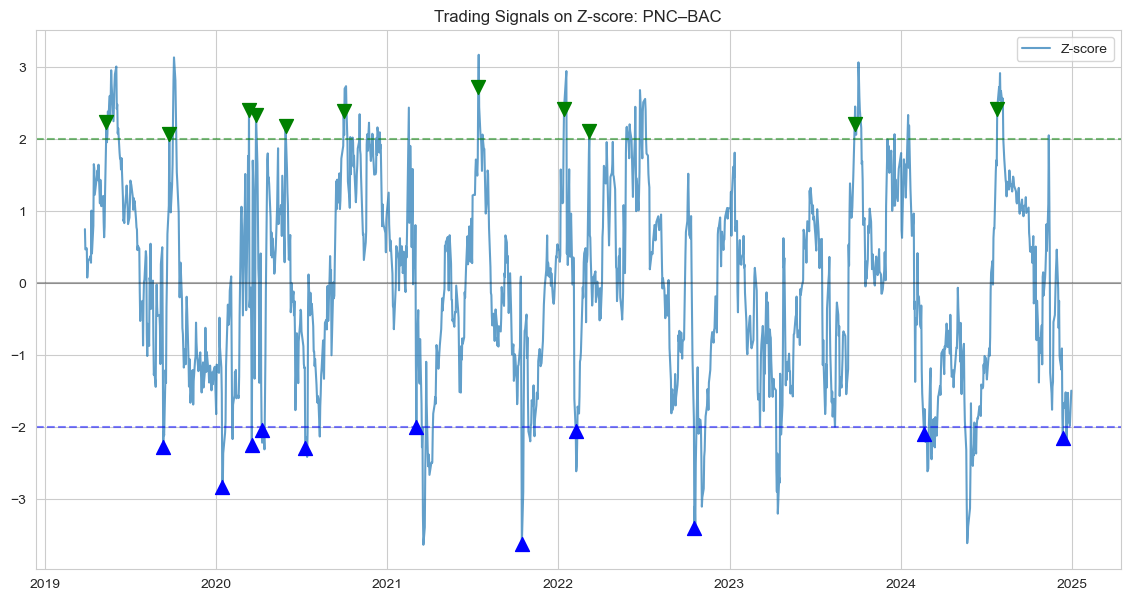

In [180]:
## Mark entry and exit points on the spread chart.

# Create a DataFrame with entry/exit points
entries = df[df['position_change'] != 0].copy()
entries['signal'] = np.where(entries['position'] == 1, 'Long Entry', 
                             np.where(entries['position'] == -1, 'Short Entry', 'Exit'))

plt.figure(figsize=(14,7))
plt.plot(df.index, df['z_score'], label='Z-score', alpha=0.7)
plt.axhline(y=2, color='g', linestyle='--', alpha=0.5)
plt.axhline(y=-2, color='b', linestyle='--', alpha=0.5)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)

# Mark entries
for idx, row in entries.iterrows():
    if row['signal'] == 'Long Entry':
        plt.scatter(idx, row['z_score'], color='blue', marker='^', s=100, zorder=5)
    elif row['signal'] == 'Short Entry':
        plt.scatter(idx, row['z_score'], color='green', marker='v', s=100, zorder=5)
    elif row['signal'] == 'Exit':
        plt.scatter(idx, row['z_score'], color='red', marker='o', s=50, zorder=5)

plt.title(f'Trading Signals on Z-score: {stock2}–{stock1}')
plt.legend()
plt.show()

[*********************100%***********************]  23 of 23 completed


Downloaded prices for 23 stocks

Found 6 cointegrated pairs:
          pair    pvalue
1   (BAC, PNC)  0.001042
5    (DB, JPM)  0.003254
3  (BMO, SCHW)  0.013604
2    (BCS, BK)  0.015699
4     (DB, GS)  0.027133
0    (BAC, CM)  0.033754

--- Processing pair: BAC – PNC ---
  Hedge ratio (β): 4.3543
  Trades: 69 | Total P&L: $-27,818.06 | Sharpe: -0.91

--- Processing pair: DB – JPM ---
  Hedge ratio (β): 12.0999
  Trades: 54 | Total P&L: $-181,315.98 | Sharpe: -1.15

--- Processing pair: BMO – SCHW ---
  Hedge ratio (β): 0.8830
  Trades: 66 | Total P&L: $-18,511.87 | Sharpe: -1.58

--- Processing pair: BCS – BK ---
  Hedge ratio (β): 4.9830
  Trades: 68 | Total P&L: $-45,959.59 | Sharpe: -0.65

--- Processing pair: DB – GS ---
  Hedge ratio (β): 31.4285
  Trades: 56 | Total P&L: $-594,116.86 | Sharpe: -1.45

--- Processing pair: BAC – CM ---
  Hedge ratio (β): 1.3362
  Trades: 60 | Total P&L: $-19,730.69 | Sharpe: -1.72

INDIVIDUAL PAIR PERFORMANCE
    Pair  Total P&L ($)    Sharpe    Ma

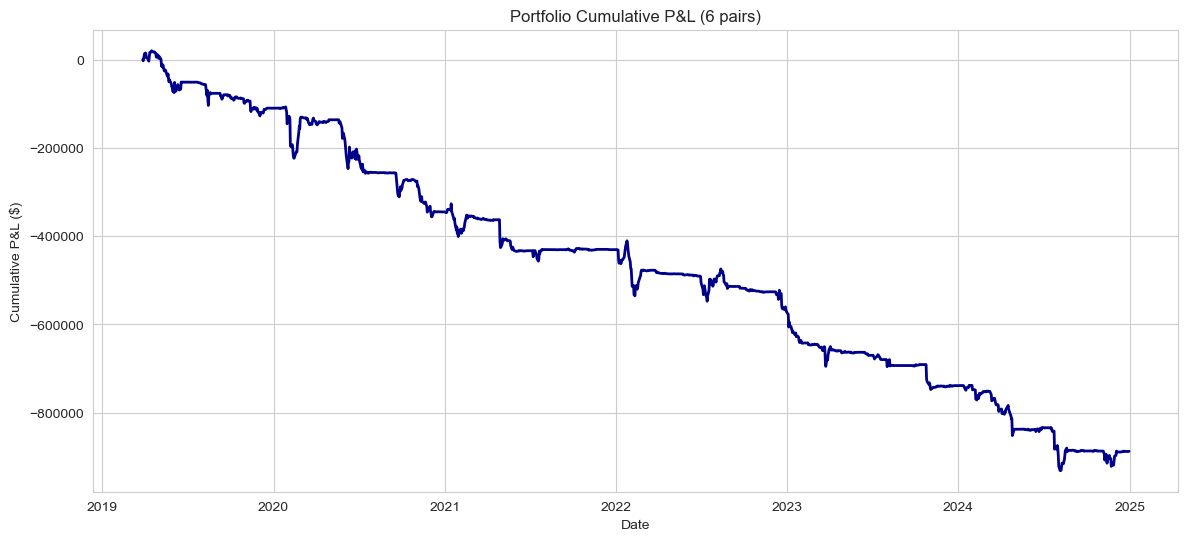

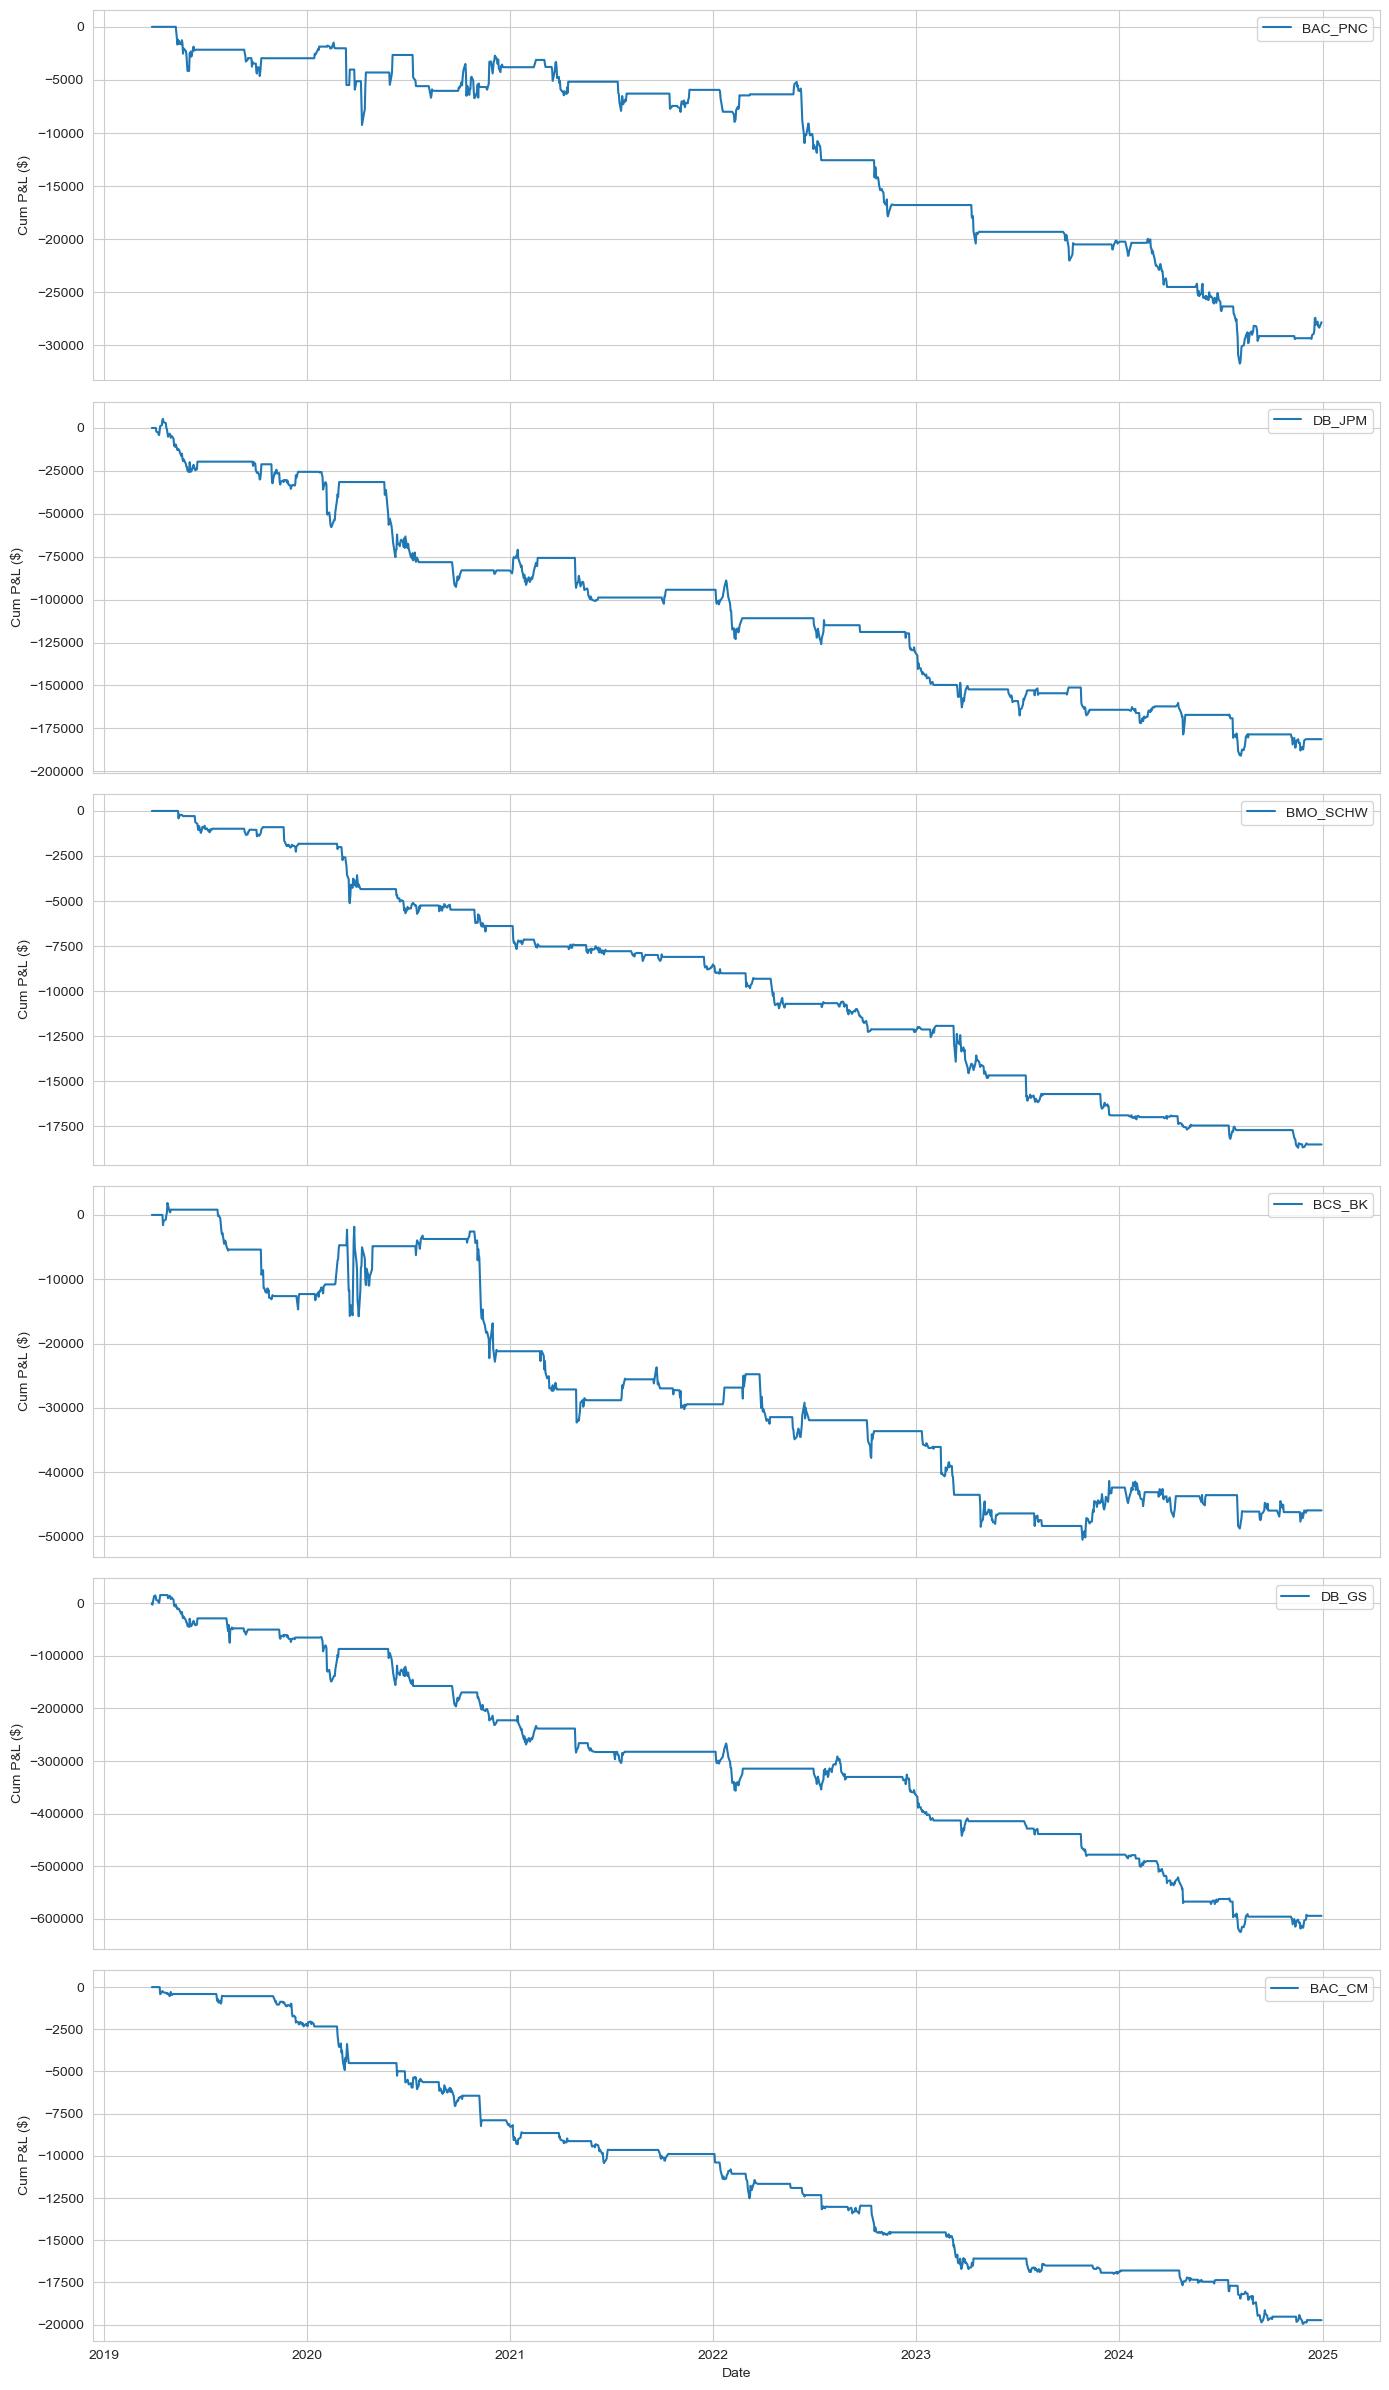

In [183]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

# ============================================================
# 1. PARAMETERS – ADJUST THESE
# ============================================================
entry_threshold = 2.0           # Enter when |z| > this
exit_threshold = 1.0            # For fixed exit: exit when |z| < this
use_trailing_stop = False       # Set True to use trailing stop
trailing_stop_distance = 1.0    # In multiples of entry_threshold
window = 60                      # Rolling window for spread stats
notional = 10000                 # Capital per pair ($)
cost_per_trade = 10              # Transaction cost per one-way trade ($)
start_date = '2019-01-01'
end_date = '2024-12-31'

# Universe (choose one)
tickers = ['JPM', 'BAC', 'WFC', 'C', 'GS', 'MS', 'USB', 'PNC', 'HSBC','RY','TD','BK','TFC','MTB','SCHW','BMO','CM','BNS','BBVA','ING','LYG','BCS','DB']          # financials
# tickers = ['AMGN', 'GILD', 'REGN', 'BIIB', 'VRTX', 'INCY', 'ALNY']    # large‑cap biopharma
# tickers = ['BMRN','NBIX','UTHR','EXEL','HALO','PTCT']                 # mid‑cap biopharma

# ============================================================
# 2. DOWNLOAD DATA
# ============================================================
prices = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)['Close']
prices = prices.dropna(axis=1, thresh=int(0.8 * len(prices)))
print(f"Downloaded prices for {prices.shape[1]} stocks")

# ============================================================
# 3. FIND COINTEGRATED PAIRS
# ============================================================
def find_cointegrated_pairs(data, pvalue_threshold=0.05):
    n = data.shape[1]
    keys = data.columns
    pairs = []
    pvalues = []
    for i in range(n):
        for j in range(i+1, n):
            stock1 = keys[i]
            stock2 = keys[j]
            result = coint(data[stock1], data[stock2])
            pvalue = result[1]
            if pvalue < pvalue_threshold:
                pairs.append((stock1, stock2))
                pvalues.append(pvalue)
    return pd.DataFrame({'pair': pairs, 'pvalue': pvalues}).sort_values('pvalue')

coint_pairs = find_cointegrated_pairs(prices, pvalue_threshold=0.05)
print(f"\nFound {len(coint_pairs)} cointegrated pairs:")
print(coint_pairs)

if len(coint_pairs) == 0:
    raise ValueError("No cointegrated pairs found – try a different universe or p‑value threshold.")

# ============================================================
# 4. BACKTEST EACH PAIR AND COLLECT RESULTS
# ============================================================
pair_pnl = {}          # daily net P&L for each pair
pair_stats = []        # summary stats per pair

for idx, row in coint_pairs.iterrows():
    stock1, stock2 = row['pair']
    print(f"\n--- Processing pair: {stock1} – {stock2} ---")
    
    # Align prices
    S1 = prices[stock1].dropna()
    S2 = prices[stock2].dropna()
    common_idx = S1.index.intersection(S2.index)
    S1 = S1[common_idx]
    S2 = S2[common_idx]
    
    # Static hedge ratio (full sample)
    S1_const = sm.add_constant(S1)
    model = sm.OLS(S2, S1_const).fit()
    hedge_ratio = model.params[stock1]
    print(f"  Hedge ratio (β): {hedge_ratio:.4f}")
    
    # Spread and z‑score
    spread = S2 - hedge_ratio * S1
    spread_mean = spread.rolling(window=window, min_periods=window).mean()
    spread_std = spread.rolling(window=window, min_periods=window).std()
    z_score = (spread - spread_mean) / spread_std
    z_score = z_score.dropna()
    
    # Prepare trading DataFrame
    df_pair = pd.DataFrame(index=z_score.index)
    df_pair['z'] = z_score
    df_pair['spread'] = spread.loc[z_score.index]
    
    # Trading simulation
    df_pair['position'] = 0
    in_position = 0
    entry_z = None
    best_z = None
    
    for i in range(1, len(df_pair)):
        date = df_pair.index[i]
        z = df_pair.loc[date, 'z']
        
        # Entry
        if in_position == 0:
            if z > entry_threshold:
                in_position = -1          # short spread
                entry_z = z
                best_z = z
            elif z < -entry_threshold:
                in_position = 1           # long spread
                entry_z = z
                best_z = z
        
        # Exit logic
        else:
            # Update best z for trailing stop
            if in_position == 1:          # long: best is highest z
                if z > best_z:
                    best_z = z
            else:                          # short: best is lowest z
                if z < best_z:
                    best_z = z
            
            if use_trailing_stop:
                if in_position == 1:
                    if z < best_z - trailing_stop_distance * entry_threshold:
                        in_position = 0
                else:  # in_position == -1
                    if z > best_z + trailing_stop_distance * entry_threshold:
                        in_position = 0
            else:
                # Fixed exit threshold
                if abs(z) < exit_threshold:
                    in_position = 0
        
        df_pair.loc[date, 'position'] = in_position
    
    # Daily P&L
    ret1 = S1.pct_change().loc[df_pair.index]
    ret2 = S2.pct_change().loc[df_pair.index]
    df_pair['ret1'] = ret1
    df_pair['ret2'] = ret2
    
    df_pair['pnl_daily'] = df_pair['position'] * (df_pair['ret2'] - hedge_ratio * df_pair['ret1']) * notional
    df_pair['position_change'] = df_pair['position'].diff().fillna(0)
    df_pair['cost'] = np.abs(df_pair['position_change']) * cost_per_trade
    df_pair['pnl_net'] = df_pair['pnl_daily'] - df_pair['cost']
    
    # Store net P&L series
    pair_name = f"{stock1}_{stock2}"
    pair_pnl[pair_name] = df_pair['pnl_net']
    
    # Compute per‑pair statistics
    cum_pnl_pair = df_pair['pnl_net'].cumsum()
    total_pnl_pair = cum_pnl_pair.iloc[-1]
    daily_ret_pair = df_pair['pnl_net'] / notional
    sharpe_pair = np.sqrt(252) * daily_ret_pair.mean() / daily_ret_pair.std() if daily_ret_pair.std() != 0 else 0
    drawdown_pair = (cum_pnl_pair.cummax() - cum_pnl_pair).max()
    num_trades_pair = (df_pair['position_change'].abs() > 0).sum()
    
    pair_stats.append({
        'Pair': pair_name,
        'Total P&L ($)': total_pnl_pair,
        'Sharpe': sharpe_pair,
        'Max DD ($)': drawdown_pair,
        'Trades': num_trades_pair
    })
    
    print(f"  Trades: {num_trades_pair} | Total P&L: ${total_pnl_pair:,.2f} | Sharpe: {sharpe_pair:.2f}")

# ============================================================
# 5. COMBINE INTO PORTFOLIO
# ============================================================
portfolio_pnl = pd.DataFrame(pair_pnl).fillna(0)
portfolio_pnl['total_pnl'] = portfolio_pnl.sum(axis=1)
portfolio_pnl['cum_total'] = portfolio_pnl['total_pnl'].cumsum()

# Portfolio metrics
total_capital = notional * len(coint_pairs)
strategy_returns = portfolio_pnl['total_pnl'] / total_capital
sharpe_port = np.sqrt(252) * strategy_returns.mean() / strategy_returns.std()
max_dd_port = (portfolio_pnl['cum_total'].cummax() - portfolio_pnl['cum_total']).max()

# ============================================================
# 6. PRINT SUMMARY TABLES
# ============================================================
print("\n" + "="*60)
print("INDIVIDUAL PAIR PERFORMANCE")
print("="*60)
pair_stats_df = pd.DataFrame(pair_stats).sort_values('Total P&L ($)', ascending=False)
print(pair_stats_df.to_string(index=False))

print("\n" + "="*60)
print("PORTFOLIO PERFORMANCE")
print("="*60)
print(f"Total P&L:              ${portfolio_pnl['cum_total'].iloc[-1]:,.2f}")
print(f"Annualised Sharpe:       {sharpe_port:.2f}")
print(f"Maximum Drawdown:       ${max_dd_port:,.2f}")
print(f"Total capital deployed: ${total_capital:,.0f} ({len(coint_pairs)} pairs × ${notional:,.0f})")

# ============================================================
# 7. PLOTS
# ============================================================
# Portfolio cumulative P&L
plt.figure(figsize=(14,6))
plt.plot(portfolio_pnl.index, portfolio_pnl['cum_total'], linewidth=2, color='darkblue')
plt.title(f'Portfolio Cumulative P&L ({len(coint_pairs)} pairs)')
plt.xlabel('Date')
plt.ylabel('Cumulative P&L ($)')
plt.grid(True)
plt.show()

# Individual pair cumulative P&L (subplots)
if len(coint_pairs) > 0:
    fig, axes = plt.subplots(len(coint_pairs), 1, figsize=(14, 4*len(coint_pairs)), sharex=True)
    if len(coint_pairs) == 1:
        axes = [axes]
    for ax, (name, col) in zip(axes, pair_pnl.items()):
        ax.plot(portfolio_pnl.index, portfolio_pnl[name].cumsum(), label=name)
        ax.set_ylabel('Cum P&L ($)')
        ax.legend()
        ax.grid(True)
    plt.xlabel('Date')
    plt.tight_layout()
    plt.show()